# Penrose Ammann Lines via A₄ Coxeter Theory

This notebook derives every parameter of the Penrose Ammann-line construction
algebraically from the A₄ root system, using the same SageMath approach as
`hexadic_diamond_coxeter.ipynb`, then reproduces the numerical Ammann-line
computation of `penrose_coxeter.ipynb`.

**References**
- Boyle & Steinhardt, *Coxeter Pairs, Ammann Patterns, and Penrose-like Tilings*, arXiv:1608.08215v4 
- Boyle & Steinhardt, *Self-Similar One-Dimensional Quasilattices*,
  arXiv:1608.08215 / arXiv:1608.08220

In [1]:
from sage.all import (
    CyclotomicField, RootSystem,
    n as numerical
)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

## 1. A₄ root system and Coxeter element

The Coxeter element of W(A₄) = S₅ is the product of all simple reflections
taken in order: cox = s₁·s₂·s₃·s₄. Its matrix representation in the ε-basis
is the 5×5 cyclic permutation P: εᵢ → εᵢ₊₁ (mod 5). This is the same matrix
used in the Penrose cut-and-project construction.

In [2]:
R = RootSystem(['A', 4])
ambient = R.ambient_space()
W = ambient.weyl_group()
s = W.simple_reflections()
cox = s[1] * s[2] * s[3] * s[4]
P = cox.matrix()
print('Coxeter element matrix P (cyclic permutation εᵢ → εᵢ₊₁):')
print(P)
# print('Order of P:', P.multiplicative_order())

Coxeter element matrix P (cyclic permutation εᵢ → εᵢ₊₁):
[0 0 0 0 1]
[1 0 0 0 0]
[0 1 0 0 0]
[0 0 1 0 0]
[0 0 0 1 0]


In [3]:
W.reflections()

Finite family {(1, -1, 0, 0, 0): [0 1 0 0 0]
[1 0 0 0 0]
[0 0 1 0 0]
[0 0 0 1 0]
[0 0 0 0 1], (0, 1, -1, 0, 0): [1 0 0 0 0]
[0 0 1 0 0]
[0 1 0 0 0]
[0 0 0 1 0]
[0 0 0 0 1], (0, 0, 1, -1, 0): [1 0 0 0 0]
[0 1 0 0 0]
[0 0 0 1 0]
[0 0 1 0 0]
[0 0 0 0 1], (0, 0, 0, 1, -1): [1 0 0 0 0]
[0 1 0 0 0]
[0 0 1 0 0]
[0 0 0 0 1]
[0 0 0 1 0], (1, 0, -1, 0, 0): [0 0 1 0 0]
[0 1 0 0 0]
[1 0 0 0 0]
[0 0 0 1 0]
[0 0 0 0 1], (0, 1, 0, -1, 0): [1 0 0 0 0]
[0 0 0 1 0]
[0 0 1 0 0]
[0 1 0 0 0]
[0 0 0 0 1], (0, 0, 1, 0, -1): [1 0 0 0 0]
[0 1 0 0 0]
[0 0 0 0 1]
[0 0 0 1 0]
[0 0 1 0 0], (1, 0, 0, -1, 0): [0 0 0 1 0]
[0 1 0 0 0]
[0 0 1 0 0]
[1 0 0 0 0]
[0 0 0 0 1], (0, 1, 0, 0, -1): [1 0 0 0 0]
[0 0 0 0 1]
[0 0 1 0 0]
[0 0 0 1 0]
[0 1 0 0 0], (1, 0, 0, 0, -1): [0 0 0 0 1]
[0 1 0 0 0]
[0 0 1 0 0]
[0 0 0 1 0]
[1 0 0 0 0]}

## 2. Eigenspaces over Q(ζ₅): parallel and perpendicular planes

P has eigenvalues ωᵏ = e^(2πik/5) for k = 0,1,2,3,4. The two real 2-planes of
interest are:

- **E∥** (k = 1,4, eigenvalue ζ₅ and ζ₅⁴): rotation by 72° — physical space
  of the Penrose tiling
- **E⊥** (k = 2,3, eigenvalue ζ₅² and ζ₅³): rotation by 144° — phason space

In [4]:
K = CyclotomicField(5)
zeta = K.gen()           # ζ₅ = e^(2πi/5)
PK = P.change_ring(K)
espaces = PK.eigenspaces_right()

print('Eigenspaces of P over Q(ζ₅):')
for ev, esp in espaces:
    print(f'  eigenvalue = {ev},  dimension = {esp.dimension()}')

# Identify E∥ (eigenvalue ζ₅) and E⊥ (eigenvalue ζ₅²)
espace_par  = dict(espaces)[zeta]
espace_perp = dict(espaces)[zeta**2]

w_par  = espace_par.basis()[0]
w_perp = espace_perp.basis()[0]
print('\nE∥ eigenvector (over Q(ζ₅)):', w_par)
print('E⊥ eigenvector (over Q(ζ₅)):', w_perp)

Eigenspaces of P over Q(ζ₅):
  eigenvalue = 1,  dimension = 1
  eigenvalue = zeta5,  dimension = 1
  eigenvalue = zeta5^2,  dimension = 1
  eigenvalue = zeta5^3,  dimension = 1
  eigenvalue = -zeta5^3 - zeta5^2 - zeta5 - 1,  dimension = 1

E∥ eigenvector (over Q(ζ₅)): (1, -zeta5^3 - zeta5^2 - zeta5 - 1, zeta5^3, zeta5^2, zeta5)
E⊥ eigenvector (over Q(ζ₅)): (1, zeta5^3, zeta5, -zeta5^3 - zeta5^2 - zeta5 - 1, zeta5^2)


## 3. Projection matrices for E∥ and E⊥

Each complex eigenvector w splits into real and imaginary parts via the complex
embedding K → ℂ. These two real 5-vectors span the corresponding eigenplane and,
after normalization, form a 2×5 orthonormal projection matrix.

In [5]:
def eigenvec_to_proj(w, K):
    """Extract orthonormal 2×5 real projection matrix from a complex eigenvector.
    Sign convention: im[1] > 0 (matches basis_parallel row ordering in penrose_coxeter.ipynb,
    where row 0 = cosines, row 1 = sines with sin(2π/5) > 0).
    SageMath may return the conjugate eigenvector, which negates im — we correct for that here.
    """
    emb = K.complex_embedding()
    w_cc = [emb(c) for c in w]
    re = np.array([float(c.real()) for c in w_cc])
    im = np.array([float(c.imag()) for c in w_cc])
    re /= np.linalg.norm(re)
    im /= np.linalg.norm(im)
    if im[1] < 0:
        im = -im
    return np.vstack([re, im])

proj_par  = eigenvec_to_proj(w_par,  K)   # 2×5, E∥
proj_perp = eigenvec_to_proj(w_perp, K)   # 2×5, E⊥

print('E∥ projection matrix (2×5):')
print(proj_par)
print('\nE⊥ projection matrix (2×5):')
print(proj_perp)

# Verify rotation angles between consecutive projected basis vectors
eps = np.eye(5)
e1_par  = proj_par  @ eps[1]; e1_par  /= np.linalg.norm(e1_par)
e2_par  = proj_par  @ eps[2]; e2_par  /= np.linalg.norm(e2_par)
e1_perp = proj_perp @ eps[1]; e1_perp /= np.linalg.norm(e1_perp)
e2_perp = proj_perp @ eps[2]; e2_perp /= np.linalg.norm(e2_perp)
angle_par  = np.degrees(np.arccos(np.clip(np.dot(e1_par,  e2_par),  -1, 1)))
angle_perp = np.degrees(np.arccos(np.clip(np.dot(e1_perp, e2_perp), -1, 1)))
print(f'\nAngle between consecutive E∥  basis vectors: {angle_par:.4f}° (expect 72°)')
print(f'Angle between consecutive E⊥ basis vectors: {angle_perp:.4f}° (expect 144°)')

E∥ projection matrix (2×5):
[[ 0.63245553  0.19543951 -0.51166727 -0.51166727  0.19543951]
 [-0.          0.60150096  0.37174803 -0.37174803 -0.60150096]]

E⊥ projection matrix (2×5):
[[ 0.63245553 -0.51166727  0.19543951  0.19543951 -0.51166727]
 [-0.          0.37174803 -0.60150096  0.60150096 -0.37174803]]

Angle between consecutive E∥  basis vectors: 72.0000° (expect 72°)
Angle between consecutive E⊥ basis vectors: 144.0000° (expect 144°)


## 4. Star vectors as projections of A₄ basis vectors

The five star vectors a_j⁺ = (cos 2πj/5, sin 2πj/5) of the Penrose Ammann
pattern are simply the projections of the A₄ basis vectors εⱼ onto E∥,
unit-normalised. Their perpendicular projections onto E⊥ give the Galois
conjugate star a_j⁻ = (cos 4πj/5, sin 4πj/5).

In [6]:
proj_eps = [proj_par @ eps[j] for j in range(5)]
scale = np.linalg.norm(proj_eps[0])          # should be √(2/5)
print(f'Scale factor ||proj_par(ε₀)|| = {scale:.6f}  (expect √(2/5) = {np.sqrt(2/5):.6f})')

a_p = np.array([v / np.linalg.norm(v) for v in proj_eps])             # 5×2, E∥ star
a_m = np.array([proj_perp @ eps[j] / np.linalg.norm(proj_perp @ eps[j])
                for j in range(5)])                                    # 5×2, E⊥ star

print('\na_p (E∥ star vectors, should be cos/sin 2πj/5):')
for j, v in enumerate(a_p):
    expected = np.array([np.cos(2*np.pi*j/5), np.sin(2*np.pi*j/5)])
    print(f'  j={j}: {v}  match={np.allclose(v, expected)}')

Scale factor ||proj_par(ε₀)|| = 0.632456  (expect √(2/5) = 0.632456)

a_p (E∥ star vectors, should be cos/sin 2πj/5):
  j=0: [1. 0.]  match=True
  j=1: [0.30901699 0.95105652]  match=True
  j=2: [-0.80901699  0.58778525]  match=True
  j=3: [-0.80901699 -0.58778525]  match=True
  j=4: [ 0.30901699 -0.95105652]  match=True


## 5. Tiling parameters m₁±, m₂±, κ₁ from cyclotomic arithmetic

The ratio of projected squared norms of d=2 vs d=1 A₄ roots equals τ² exactly
in Q(ζ₅). This fixes the golden ratio, and from it all Ammann-line parameters
follow. Specifically:

- √5 = ζ + ζ⁴ − ζ² − ζ³  (real element of Q(ζ₅))
- m₁⁺ = (5 − √5)/10,  m₂⁺ = 1/√5  →  m₂⁺/m₁⁺ = τ
- m₁⁻, m₂⁻ are their Galois conjugates under √5 → −√5
- κ₁ = 1/τ  (density of long tiles in each Fibonacci quasilattice)

In [7]:
# Projected squared norms of A₄ roots onto E∥
norm_sq_adj = (1 - zeta)    * (1 - zeta**4)   # d=1 root: 2 − ζ − ζ⁴
norm_sq_non = (1 - zeta**2) * (1 - zeta**3)   # d=2 root: 2 − ζ² − ζ³
tau_sq = norm_sq_non / norm_sq_adj
print('|π(d=1 root)|² =', norm_sq_adj, '≈', float(numerical(norm_sq_adj).real()))
print('|π(d=2 root)|² =', norm_sq_non, '≈', float(numerical(norm_sq_non).real()))
print('τ²             =', tau_sq,       '≈', float(numerical(tau_sq).real()), ' (expect ≈2.618)')

# √5 as a real element of Q(ζ₅)
sqrt5 = zeta + zeta**4 - zeta**2 - zeta**3
print('\n√5 in Q(ζ₅)    =', sqrt5, '≈', float(numerical(sqrt5).real()))

# m₁⁺, m₂⁺, τ, κ₁ in Q(ζ₅)
m1_plus_exact  = (5 - sqrt5) / 10
m2_plus_exact  = 1 / sqrt5
tau_exact      = (1 + sqrt5) / 2
sigma_exact    = (1 - sqrt5) / 2
kappa1_exact   = 1 / tau_exact
m1_minus_exact = (5 + sqrt5) / 10
m2_minus_exact = -1 / sqrt5

def to_float(x):
    return float(numerical(x).real())

print('\nIn Q(ζ₅):')
print('  m₁⁺ =', m1_plus_exact,  '≈', to_float(m1_plus_exact),  ' (expect (5−√5)/10 ≈', (5-np.sqrt(5))/10, ')')
print('  m₂⁺ =', m2_plus_exact,  '≈', to_float(m2_plus_exact),  ' (expect 1/√5    ≈', 1/np.sqrt(5), ')')
print('  τ   =', tau_exact,       '≈', to_float(tau_exact))
print('  κ₁  =', kappa1_exact,    '≈', to_float(kappa1_exact))

# Verify m₂⁺/m₁⁺ = τ symbolically
ratio = m2_plus_exact / m1_plus_exact
print('\nm₂⁺/m₁⁺ =', ratio, '=', ratio == tau_exact, '(symbolic equality with τ)')

# Galois conjugates: √5 → −√5
print('\nGalois conjugates (√5 → −√5):')
print('  m₁⁻ =', m1_minus_exact, '≈', to_float(m1_minus_exact))
print('  m₂⁻ =', m2_minus_exact, '≈', to_float(m2_minus_exact))

# Extract floats for downstream numpy computation
M1_PLUS  = to_float(m1_plus_exact)
M2_PLUS  = to_float(m2_plus_exact)
M1_MINUS = to_float(m1_minus_exact)
M2_MINUS = to_float(m2_minus_exact)
TAU      = to_float(tau_exact)
SIGMA    = to_float(sigma_exact)
KAPPA_1  = to_float(kappa1_exact)

|π(d=1 root)|² = zeta5^3 + zeta5^2 + 3 ≈ 1.3819660112501053
|π(d=2 root)|² = -zeta5^3 - zeta5^2 + 2 ≈ 3.618033988749895
τ²             = -zeta5^3 - zeta5^2 + 1 ≈ 2.618033988749895  (expect ≈2.618)

√5 in Q(ζ₅)    = -2*zeta5^3 - 2*zeta5^2 - 1 ≈ 2.2360679774997894

In Q(ζ₅):
  m₁⁺ = 1/5*zeta5^3 + 1/5*zeta5^2 + 3/5 ≈ 0.27639320225002095  (expect (5−√5)/10 ≈ 0.276393202250021 )
  m₂⁺ = -2/5*zeta5^3 - 2/5*zeta5^2 - 1/5 ≈ 0.44721359549995804  (expect 1/√5    ≈ 0.4472135954999579 )
  τ   = -zeta5^3 - zeta5^2 ≈ 1.6180339887498947
  κ₁  = -zeta5^3 - zeta5^2 - 1 ≈ 0.6180339887498947

m₂⁺/m₁⁺ = -zeta5^3 - zeta5^2 = True (symbolic equality with τ)

Galois conjugates (√5 → −√5):
  m₁⁻ = -1/5*zeta5^3 - 1/5*zeta5^2 + 2/5 ≈ 0.723606797749979
  m₂⁻ = 2/5*zeta5^3 + 2/5*zeta5^2 + 1/5 ≈ -0.44721359549995804


## 6. Translation vector q₀ and decomposition into E∥ ⊕ E⊥

The offset vector q₀ is expressed as a rational combination of the four
fundamental roots of A₄, then projected onto E∥ (translational phase) and
E⊥ (phason phase). The Galois conjugation redistributes the same rational
coefficients very differently between the two subspaces: |q₀⁻| >> |q₀⁺|.

In [8]:
from sage.all import QQ

# Simple roots of A₄ from the ambient space object (1-indexed: α₁…α₄)
# αᵢ = εᵢ − εᵢ₊₁  →  e.g. α₁ = (1,−1,0,0,0)
# The Coxeter paper's fundamental roots fᵢ are the negative simple roots: fᵢ = −αᵢ
# e.g. f₁ = (−1,+1,0,0,0),  f₂ = (0,−1,+1,0,0), …
alpha = ambient.simple_roots()
print('A₄ simple roots (αᵢ = εᵢ − εᵢ₊₁):')
for i in range(1, 5):
    print(f'  α{i} =', alpha[i].to_vector())

# Exact rational coefficients for q₀ = (1/3)f₁ + (1/7)f₂ + (1/5)f₃ + (2/5)f₄
q_0_coeffs = {1: QQ(1)/3, 2: QQ(1)/7, 3: QQ(1)/5, 4: QQ(2)/5}
q5_0_sage = sum(-q_0_coeffs[i] * alpha[i].to_vector() for i in range(1, 5))
print('\nq5_0 (exact, in Q):', q5_0_sage)

q5_0 = np.array([float(c) for c in q5_0_sage])
qp_0 = proj_par  @ q5_0    # parallel part (translational)
qm_0 = proj_perp @ q5_0    # perpendicular part (phason)

print('q5_0 (float):', q5_0)
print('q₀⁺ (E∥, translational):', qp_0, '  |q₀⁺| =', np.linalg.norm(qp_0))
print('q₀⁻ (E⊥, phason):       ', qm_0, '  |q₀⁻| =', np.linalg.norm(qm_0))
print('Ratio |q₀⁻|/|q₀⁺| =', np.linalg.norm(qm_0)/np.linalg.norm(qp_0))

A₄ simple roots (αᵢ = εᵢ − εᵢ₊₁):
  α1 = (1, -1, 0, 0, 0)
  α2 = (0, 1, -1, 0, 0)
  α3 = (0, 0, 1, -1, 0)
  α4 = (0, 0, 0, 1, -1)

q5_0 (exact, in Q): (-1/3, 4/21, -2/35, -1/5, 2/5)
q5_0 (float): [-0.33333333  0.19047619 -0.05714286 -0.2         0.4       ]
q₀⁺ (E∥, translational): [ 0.03615545 -0.07292191]   |q₀⁺| = 0.08139300605413423
q₀⁻ (E⊥, phason):        [-0.56320173 -0.16381877]   |q₀⁻| = 0.5865430716813163
Ratio |q₀⁻|/|q₀⁺| = 7.206308012401069


## 7. Phase parameters χ₁± for each Ammann direction

For each of the 5 Ammann families j, the translational phase χ₁ⱼ⁺ and the
phason phase χ₁ⱼ⁻ are computed from q₀⁺ and q₀⁻ via Eq. (18) of the
Coxeter paper. χ⁺ produces only a rigid shift of the multigrid; χ⁻ enters
the floor function and controls the L/S ordering of tiles.

In [9]:
b_p = TAU   * a_p    # b⁺ⱼ = τ · a⁺ⱼ
b_m = SIGMA * a_m    # b⁻ⱼ = σ · a⁻ⱼ
α, β = 0, 0

χ_1p = np.zeros(5)
χ_1m = np.zeros(5)
for i in range(5):
    χ_1p[i] = (np.dot(M1_PLUS*a_p[i]  + M2_PLUS*b_p[i],  qp_0) - (M1_PLUS*α + M2_PLUS*β)) / M1_PLUS
    χ_1m[i] = (np.dot(M1_MINUS*a_m[i] + M2_MINUS*b_m[i], qm_0) - (M1_MINUS*α + M2_MINUS*β)) / M1_MINUS

print('χ₁⁺ (translational phases):', χ_1p)
print('χ₁⁻ (phason phases):       ', χ_1m)

χ₁⁺ (translational phases): [ 0.13081165 -0.21049797 -0.26090655  0.04924886  0.29134402]
χ₁⁻ (phason phases):        [-0.77832564  0.49660881 -0.02520429 -0.45582741  0.76274854]


## 8. Ammann line positions: 1D quasilattice formula

For each family j and index n ∈ [-10, 10], the signed distance x[j,n] of the
n-th Ammann line from the origin along direction a⁺ⱼ is given by Eq. (14)
of arXiv:1608.08215:

    x[j,n] = m₁⁺(n − χ₁ⱼ⁺) + (m₂⁺ − m₁⁺)(⌊κ₁(n − χ₁ⱼ⁻)⌋ + 0.5)

The floor function makes lines alternate between the long (L = m₂⁺) and short
(S = m₁⁺) spacings in the Fibonacci ratio.

In [10]:
n_range = (-10, 10)
ns = np.arange(n_range[0], n_range[1] + 1)
x = np.zeros((5, len(ns)))
for i in range(5):
    x[i,:] = M1_PLUS*(ns - χ_1p[i]) + (M2_PLUS - M1_PLUS)*(np.floor(KAPPA_1*(ns - χ_1m[i])) + 0.5)

print('x array (5 families × 21 positions):')
print(x)

x array (5 families × 21 positions):
[[-3.73959964 -3.46320643 -3.01599284 -2.56877924 -2.29238604 -1.84517244
  -1.39795885 -1.12156565 -0.67435205 -0.39795885  0.04925475  0.49646834
   0.77286154  1.22007514  1.49646834  1.94368194  2.39089553  2.66728874
   3.11450233  3.56171593  3.83810913]
 [-3.81608437 -3.36887077 -3.09247757 -2.64526398 -2.36887077 -1.92165718
  -1.47444358 -1.19805038 -0.75083679 -0.30362319 -0.02722999  0.41998361
   0.69637681  1.14359041  1.590804    1.8671972   2.3144108   2.76162439
   3.0380176   3.48523119  3.76162439]
 [-3.80215178 -3.35493819 -2.90772459 -2.63133139 -2.18411779 -1.90772459
  -1.460511   -1.0132974  -0.7369042  -0.2896906   0.15752299  0.4339162
   0.88112979  1.15752299  1.60473659  2.05195018  2.32834339  2.77555698
   3.05195018  3.49916378  3.94637737]
 [-3.71705623 -3.44066303 -2.99344944 -2.71705623 -2.26984264 -1.82262904
  -1.54623584 -1.09902225 -0.65180865 -0.37541545  0.07179815  0.34819135
   0.79540494  1.24261854  1.5190

## 9. Plot Ammann lines

Each value x[j,n] is the signed distance from the origin along the normal a⁺ⱼ.
The corresponding Ammann line passes through x[j,n]·a⁺ⱼ and runs perpendicular
to a⁺ⱼ. The five families together form the pentagrid underlying the Penrose tiling.

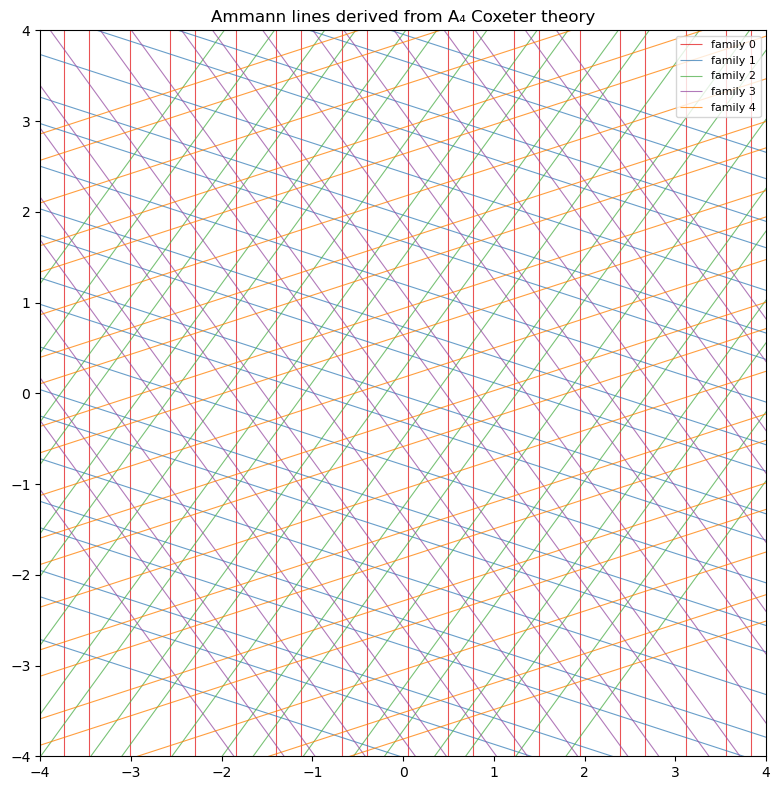

In [11]:
HALF_LEN = 6.0
COLORS = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']

fig, ax = plt.subplots(figsize=(8, 8))
for j in range(5):
    normal  = a_p[j]
    tangent = np.array([-normal[1], normal[0]])
    segs = [[xn*normal - HALF_LEN*tangent, xn*normal + HALF_LEN*tangent]
            for xn in x[j]]
    ax.add_collection(LineCollection(segs, color=COLORS[j], linewidth=0.8,
                                     alpha=0.75, label=f'family {j}'))
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_aspect('equal')
ax.legend(loc='upper right', fontsize=8)
ax.set_title('Ammann lines derived from A₄ Coxeter theory')
plt.tight_layout()
plt.show()

## 10. Dualization constant C and rhomb side length

The pentagrid is dualized to the Penrose tiling via Eq. (32) of arXiv:1608.08215:

    x′ = −q₀⁺ + (m̄⁺/γ) Σⱼ Kⱼ eⱼ

where:
- **Kⱼ(r)** = integer cell index of point r in family j (count of Ammann lines
  of family j lying "below" r along direction a_p[j])
- **m̄⁺** = κ₁·m₂⁺ + κ₂·m₁⁺ — average step size of the Fibonacci quasilattice
- **γ = 5/2** — frame constant: Σⱼ eⱼᵅ eⱼᵝ = γ δᵅᵝ (Eq. 25)
- **C = m̄⁺/γ** — dualization scale; equals the side length of every rhomb tile

Each bounded multigrid cell maps to one vertex. The rhomb at the intersection of
families j and k has four vertices whose K-tuples differ only in their j and k
components, so its side vectors are C·a_p[j] and C·a_p[k].

In [12]:
KAPPA_2     = 2.0 - TAU                              # κ₂ = 2 − τ
M_BAR_PLUS  = KAPPA_1 * M2_PLUS + KAPPA_2 * M1_PLUS  # m̄⁺
GAMMA_COEFF = 5.0 / 2.0                              # γ
C_DUAL      = M_BAR_PLUS / GAMMA_COEFF               # Eq. (32) scale = rhomb side length

print(f'κ₂      = {KAPPA_2:.6f}')
print(f'm̄⁺     = {M_BAR_PLUS:.6f}')
print(f'C_DUAL  = {C_DUAL:.6f}  (rhomb side length)')

κ₂      = 0.381966
m̄⁺     = 0.381966
C_DUAL  = 0.152786  (rhomb side length)


## 11. Pentagrid cell indices and rhomb vertices

For each pair of families (j, k) and each pair of Ammann line indices (idx_j, idx_k),
the intersection point r_int is the solution of the 2×2 system:

    [a_p[j]] · r  =  x[j, idx_j]
    [a_p[k]] · r  =  x[k, idx_k]

The integer cell index for family i at point r is:

    Kᵢ(r) = searchsorted(x[i], a_p[i]·r, side='right')

which counts the Ammann lines of family i that lie strictly below r.
The four cells meeting at r_int are obtained by independently decrementing
Kⱼ and Kₖ by 0 or 1. Each cell K = (K₀,…,K₄) dualizes to the vertex

    v(K) = C · Σᵢ Kᵢ · a_p[i] − q₀⁺

and the four vertices form one rhomb tile. The tile is **fat** (72° acute angle)
when the cyclic distance |j−k| mod 5 = 1, and **thin** (36°) when it equals 2.

In [13]:
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

tiles = []   # list of dicts: {"verts": (4,2), "type": "fat"|"thin"}

for j in range(5):
    for k in range(j + 1, 5):
        A = np.vstack([a_p[j], a_p[k]])          # 2x2 system matrix
        if abs(np.linalg.det(A)) < 1e-10:
            continue
        A_inv = np.linalg.inv(A)

        for idx_j in range(len(ns)):
            for idx_k in range(len(ns)):
                # 2D intersection of Ammann lines j,idx_j and k,idx_k
                r_int = A_inv @ np.array([x[j, idx_j], x[k, idx_k]])

                if np.linalg.norm(r_int) > 3.5:  # crop; display is (-4,4)^2
                    continue

                # Cell index Ki for every family at r_int.
                # For i!=j,k: searchsorted on the projected coordinate.
                # For i=j,k: set exactly -- r_int lies on line idx_j/idx_k by
                #             construction, but floating point can make the dot
                #             product land just below x[j,idx_j], causing
                #             searchsorted to return idx_j instead of idx_j+1.
                K_base = np.array([
                    np.searchsorted(x[i], np.dot(a_p[i], r_int), side='right')
                    for i in range(5)
                ])
                K_base[j] = idx_j + 1   # exact: r_int is on line j at idx_j
                K_base[k] = idx_k + 1   # exact: r_int is on line k at idx_k

                # 4 vertices: vary j and k components independently by +/-1
                verts = []
                for dj, dk in [(0, 0), (1, 0), (1, 1), (0, 1)]:
                    K = K_base.copy()
                    K[j] += dj - 1
                    K[k] += dk - 1
                    v = C_DUAL * sum(K[i] * a_p[i] for i in range(5)) - qp_0
                    verts.append(v)

                # Cyclic distance between j and k determines tile type
                d = min((k - j) % 5, (j - k) % 5)
                rtype = 'fat' if d == 1 else 'thin'
                tiles.append({'verts': np.array(verts), 'type': rtype})

n_fat  = sum(1 for t in tiles if t['type'] == 'fat')
n_thin = sum(1 for t in tiles if t['type'] == 'thin')
print(f'Total tiles: {len(tiles)}')
print(f'  fat : {n_fat},  thin : {n_thin},  ratio : {(n_fat/n_thin).numerical_approx():.4f}  (expect tau ~ {TAU:.4f})')

Total tiles: 2030
  fat : 1255,  thin : 775,  ratio : 1.6194  (expect tau ~ 1.6180)


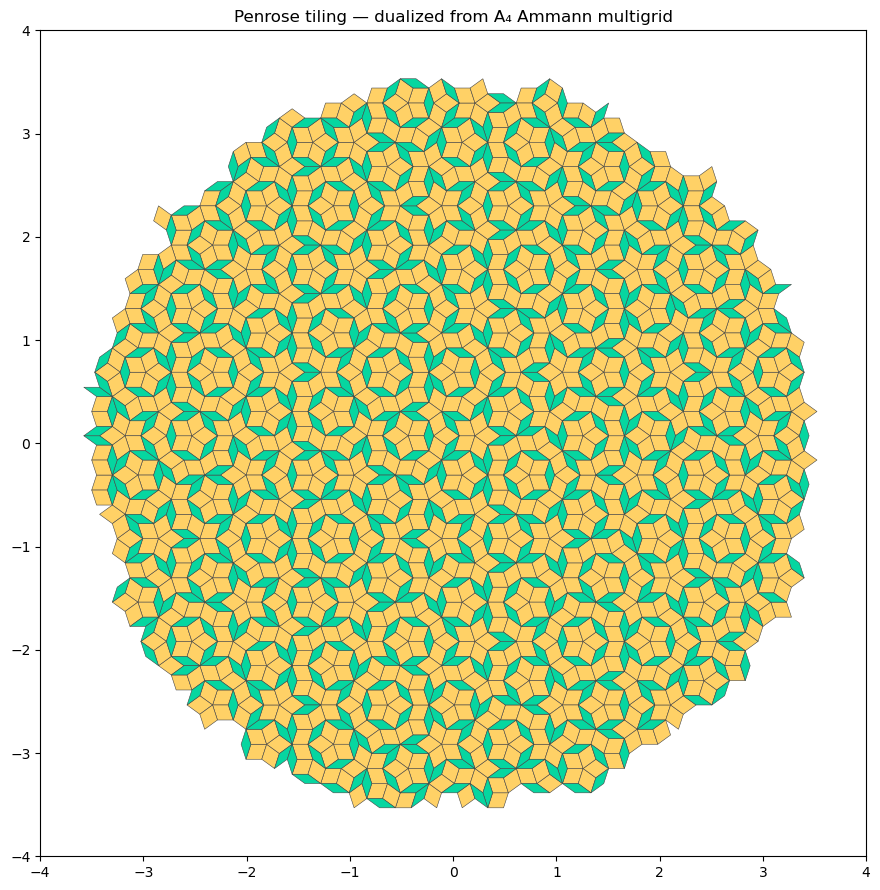

In [14]:
fig, ax = plt.subplots(figsize=(9, 9))

fat_patches  = [Polygon(t['verts']) for t in tiles if t['type'] == 'fat']
thin_patches = [Polygon(t['verts']) for t in tiles if t['type'] == 'thin']

ax.add_collection(PatchCollection(fat_patches,  facecolor='#ffd166',
                                  edgecolor='#444', linewidth=0.4))
ax.add_collection(PatchCollection(thin_patches, facecolor='#06d6a0',
                                  edgecolor='#444', linewidth=0.4))

ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_aspect('equal')
ax.set_title('Penrose tiling — dualized from A₄ Ammann multigrid')
plt.tight_layout()
plt.show()